In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp "/content/drive/MyDrive/Vegetable_Images.zip" /content/


In [ ]:
!unzip Vegetable_Images.zip -d /content/


Streaming output truncated to the last 5000 lines.
  inflating: /content/Vegetable Images/validation/Pumpkin/1255.jpg  
  inflating: /content/__MACOSX/Vegetable Images/validation/Pumpkin/._1255.jpg  
  inflating: /content/Vegetable Images/validation/Pumpkin/1269.jpg  
  inflating: /content/__MACOSX/Vegetable Images/validation/Pumpkin/._1269.jpg  
  inflating: /content/Vegetable Images/validation/Pumpkin/1282.jpg  
  inflating: /content/__MACOSX/Vegetable Images/validation/Pumpkin/._1282.jpg  
  inflating: /content/Vegetable Images/validation/Pumpkin/1296.jpg  
  inflating: /content/__MACOSX/Vegetable Images/validation/Pumpkin/._1296.jpg  
  inflating: /content/Vegetable Images/validation/Pumpkin/1297.jpg  
  inflating: /content/__MACOSX/Vegetable Images/validation/Pumpkin/._1297.jpg  
  inflating: /content/Vegetable Images/validation/Pumpkin/1283.jpg  
  inflating: /content/__MACOSX/Vegetable Images/validation/Pumpkin/._1283.jpg  
  inflating: /content/Vegetable Images/validation/Pumpk

In [ ]:
import tensorflow as tf

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available:", tf.test.is_gpu_available())

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True
GPU available: True


In [ ]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 8

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Vegetable Images/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Vegetable Images/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Vegetable Images/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("TRAIN:", train_ds.class_names)
print("TEST :", test_ds.class_names)
print("Same order?", train_ds.class_names == test_ds.class_names)

Found 15000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
TRAIN: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
TEST : ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Same order? True


In [ ]:
class_names = train_ds.class_names

import json
with open("labels.json","w") as f:
  json.dump(class_names,f)

print(class_names)

['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

In [ ]:
num_classes = 15

data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

preprocess = tf.keras.layers.Rescaling(1./127.5, offset=-1)

model = tf.keras.Sequential([
    data_aug,
    preprocess,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 27ms/step - accuracy: 0.8981 - loss: 0.3587 - val_accuracy: 0.9940 - val_loss: 0.0183
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 26ms/step - accuracy: 0.9854 - loss: 0.0465 - val_accuracy: 0.9937 - val_loss: 0.0171
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9884 - loss: 0.0373 - val_accuracy: 0.9950 - val_loss: 0.0175
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9880 - loss: 0.0349 - val_accuracy: 0.9930 - val_loss: 0.0194
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9900 - loss: 0.0322 - val_accuracy: 0.9983 - val_loss: 0.0071


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Stage 1 Test accuracy:", test_acc)

375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9955 - loss: 0.0162
Stage 1 Test accuracy: 0.9963333606719971


In [ ]:
base_model.trainable = True

# Fine-tune only last 40 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.8664 - loss: 0.5618 - val_accuracy: 0.9967 - val_loss: 0.0122
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 38ms/step - accuracy: 0.9502 - loss: 0.1661 - val_accuracy: 0.9967 - val_loss: 0.0114
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 38ms/step - accuracy: 0.9700 - loss: 0.1075 - val_accuracy: 0.9967 - val_loss: 0.0100
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9705 - loss: 0.0909 - val_accuracy: 0.9980 - val_loss: 0.0085
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 38ms/step - accuracy: 0.9807 - loss: 0.0625 - val_accuracy: 0.9973 - val_loss: 0.0065
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9818 - loss: 0.0633 - val_accuracy: 0.9970 - val_loss: 0.0070
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 40ms/step - accuracy: 0.9840 - loss: 0.0483 - val_accuracy: 0.9977 - val_loss: 0.0067
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.9866 -

In [ ]:
test_loss2, test_acc2 = model.evaluate(test_ds)
print("Stage 2 Test accuracy:", test_acc2)


375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9982 - loss: 0.0049
Stage 2 Test accuracy: 0.9983333349227905


Report (TRAIN order):
              precision    recall  f1-score   support

        Bean       1.00      1.00      1.00       200
Bitter_Gourd       1.00      0.99      0.99       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       1.00      1.00      1.00       200
    Broccoli       1.00      1.00      1.00       200
     Cabbage       1.00      1.00      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       0.99      0.99      0.99       200
    Cucumber       1.00      1.00      1.00       200
      Papaya       1.00      1.00      1.00       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       0.99      0.99      0.99       200
      Radish       1.00      1.00      1.00       200
      Tomato       1.00      0.99      1.00       200

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weig

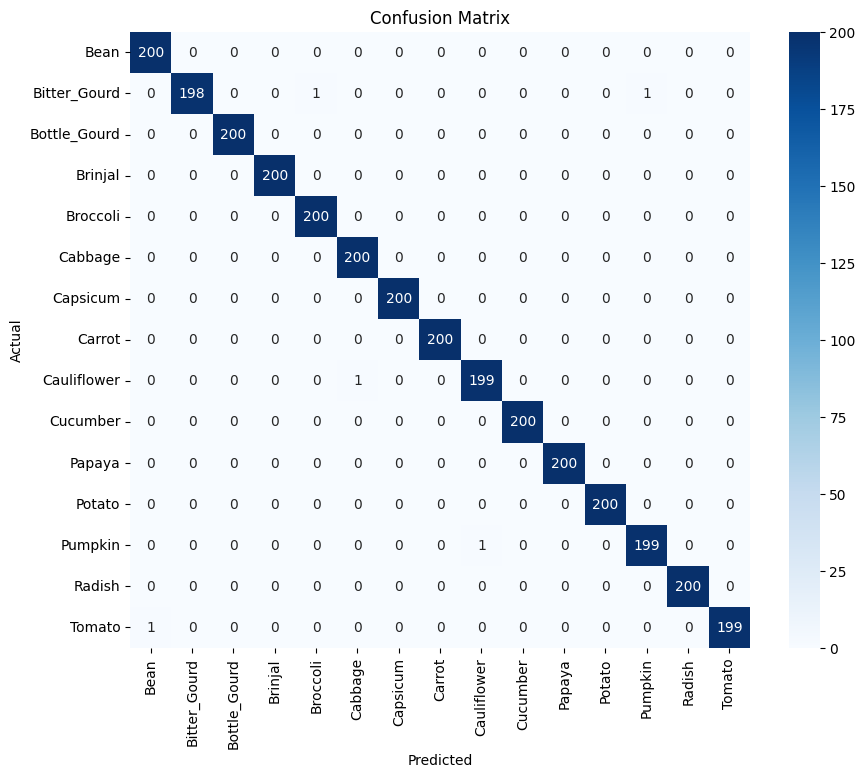

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# The 'class_names' variable is already defined in cell pFxNpWv7Fwn2
# and holds the correct class labels from 'train_ds.class_names' (and confirmed
# to be the same as 'test_ds.class_names' before prefetching). We can use this
# 'class_names' directly for target names and for building the index map.

# Use the globally available 'class_names' for consistent ordering.
target_labels = class_names

# Create an identity map as class_names are already ordered consistently
idx_map = {i: i for i, _ in enumerate(target_labels)}

# test_ds was already prefetched in gN-FDuPiFvX1, so this line is redundant.
# test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# Predict
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)  # model outputs are in TRAIN order

# Collect y_true from dataset
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# Remap y_true from TEST order -> TRAIN order
# Given idx_map is identity, this will effectively be y_true itself.
y_true_mapped = np.vectorize(idx_map.get)(y_true)

print("Report (TRAIN order):")
print(classification_report(y_true_mapped, y_pred, target_names=target_labels))

# Confusion Matrix visualization
cm = confusion_matrix(y_true_mapped, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_labels,
            yticklabels=target_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("culina_ingredients_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved culina_ingredients_model.tflite")


NameError: name 'model' is not defined

In [ ]:
import numpy as np

interpreter = tf.lite.Interpreter(model_path="culina_ingredients_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input:", input_details[0]['shape'], input_details[0]['dtype'])
print("Output:", output_details[0]['shape'], output_details[0]['dtype'])


Input: [  1 224 224   3] <class 'numpy.float32'>
Output: [ 1 15] <class 'numpy.float32'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
import os, shutil

export_dir = "culina_exported"

if os.path.exists(export_dir):
    shutil.rmtree(export_dir)

# Keras 3 export (TF SavedModel)
model.export(export_dir)
print("Exported to", export_dir)



Saved artifact at 'culina_exported'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  140622431060432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622131154768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622131156112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622131156304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622433355920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622433369168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622433369360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622433369744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622433367632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622433369552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1406224310